# Score vs Object Score Correlation

This notebook visualizes how the object difficulty score relates to the object file stored in a `score_results.json` file.


Total objects: 22815
                                          image_path  object_id      area  \
0  /home/khanh/Projects/DifficultyAgri/datasets/m...          0  0.000624   
1  /home/khanh/Projects/DifficultyAgri/datasets/m...          1  0.000474   
2  /home/khanh/Projects/DifficultyAgri/datasets/m...          2  0.000391   
3  /home/khanh/Projects/DifficultyAgri/datasets/m...          3  0.000119   
4  /home/khanh/Projects/DifficultyAgri/datasets/m...          4  0.000597   

      width    height  difficulty  
0  0.031944  0.019531    0.249901  
1  0.031944  0.014844    0.298317  
2  0.027778  0.014063    0.256275  
3  0.013889  0.008594    0.588872  
4  0.034722  0.017188    0.269881  

=== Correlation Results ===
Pearson correlation: -0.4983 (p=0.0000e+00)
Spearman correlation: -0.6797 (p=0.0000e+00)


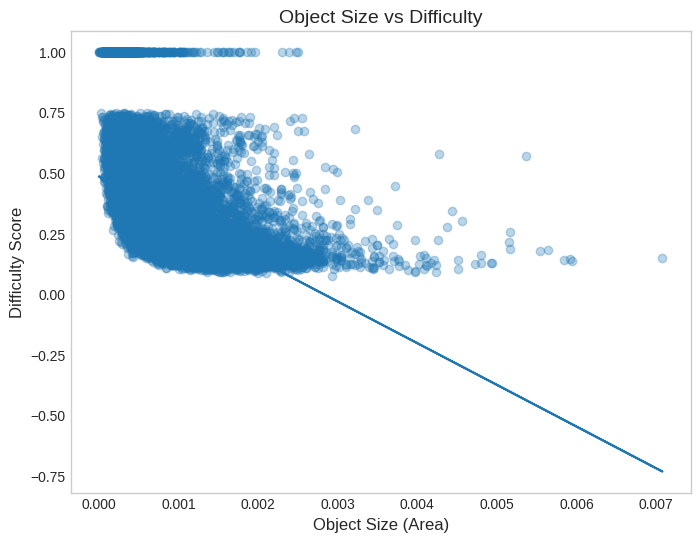

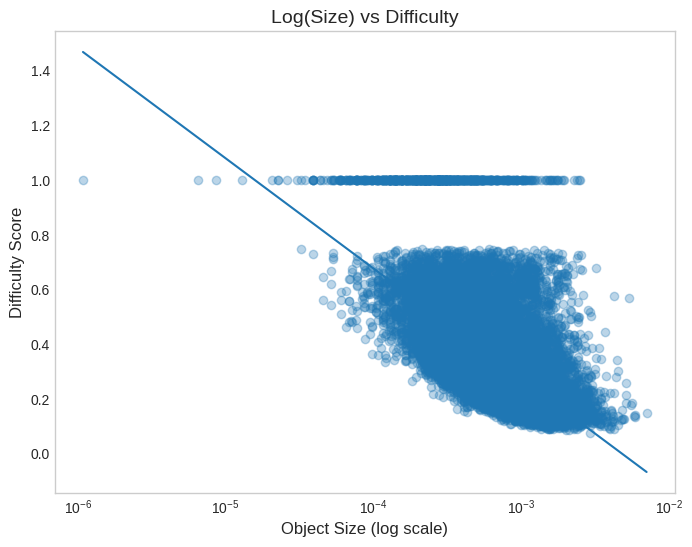


=== Avg Difficulty per Size Bin ===
size_bin
(-0.00099892, 0.000406]    0.534750
(0.000406, 0.000621]       0.376061
(0.000621, 0.000881]       0.302578
(0.000881, 0.00125]        0.252956
(0.00125, 0.00708]         0.214291
Name: difficulty, dtype: float64


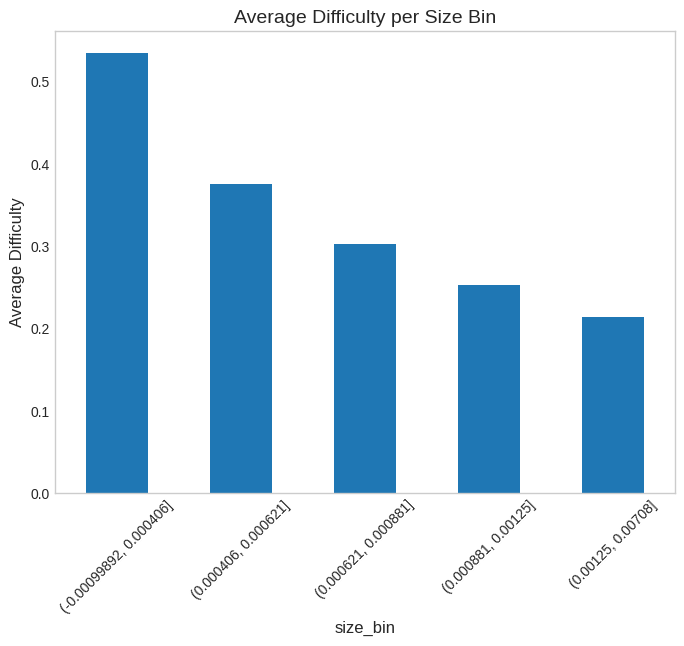

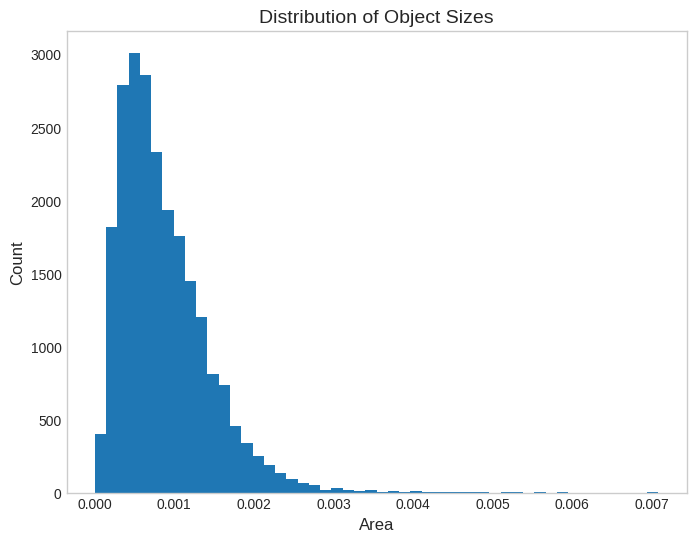

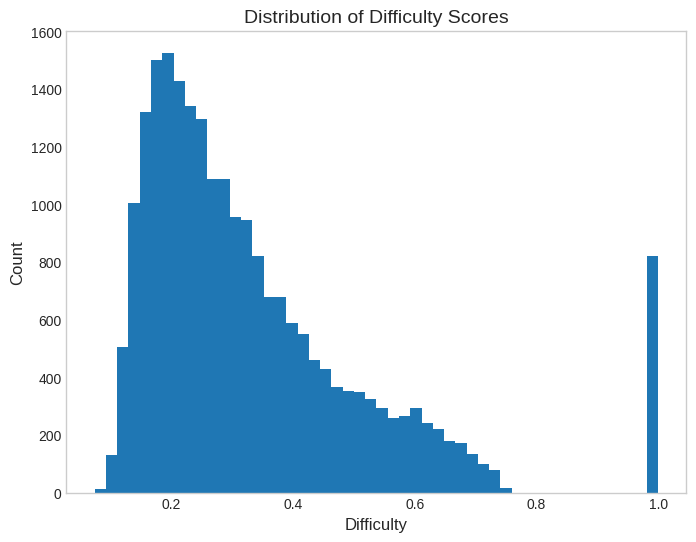


=== Interpretation Guide ===
→ Smaller objects tend to be more difficult (negative correlation).

NOTE:
- If correlation is weak, your difficulty metric likely depends on other factors
  like false positives, occlusion, or object density.
- Log-scale analysis is usually more reliable for detection datasets.


In [12]:
# =====================================================
# Object Size vs Difficulty Correlation Notebook
# =====================================================

# =========================
# 1. Imports
# =========================
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# =========================
# 2. Load JSON
# =========================
json_path = "/home/khanh/Projects/DifficultyAgri/results/12_multiseed_score_vs_noscore_copy_paste_exp_apple_withaug/seed_123/Step_3_Scoring_Dataset/score_results.json"  # <-- CHANGE THIS PATH

with open(json_path, "r") as f:
    data = json.load(f)

# =========================
# 3. Extract object-level data
# =========================
records = []

for img in data["image_difficulties"]:
    for obj in img["objects_score"]:
        bbox = obj["bounding_box"]
        
        width = bbox["width"]
        height = bbox["height"]
        
        # YOLO normalized area
        area = width * height
        
        records.append({
            "image_path": obj["image_path"],
            "object_id": obj["object_id"],
            "area": area,
            "width": width,
            "height": height,
            "difficulty": obj["difficulty_score"]
        })

df = pd.DataFrame(records)

print("===================================")
print("Total objects:", len(df))
print(df.head())
print("===================================")

# =========================
# 4. Correlation Analysis
# =========================
pearson_corr, p_val_p = pearsonr(df["area"], df["difficulty"])
spearman_corr, p_val_s = spearmanr(df["area"], df["difficulty"])

print("\n=== Correlation Results ===")
print(f"Pearson correlation: {pearson_corr:.4f} (p={p_val_p:.4e})")
print(f"Spearman correlation: {spearman_corr:.4f} (p={p_val_s:.4e})")

# =========================
# 5. Scatter Plot + Linear Trend
# =========================
plt.figure(figsize=(8, 6))

plt.scatter(df["area"], df["difficulty"], alpha=0.3)

# Linear regression line
z = np.polyfit(df["area"], df["difficulty"], 1)
p = np.poly1d(z)
plt.plot(df["area"], p(df["area"]))

plt.xlabel("Object Size (Area)")
plt.ylabel("Difficulty Score")
plt.title("Object Size vs Difficulty")

plt.grid()
plt.show()

# =========================
# 6. Log-scale Analysis (important)
# =========================
plt.figure(figsize=(8, 6))

plt.scatter(df["area"], df["difficulty"], alpha=0.3)

plt.xscale("log")

# Fit in log space
z_log = np.polyfit(np.log(df["area"]), df["difficulty"], 1)
p_log = np.poly1d(z_log)

x_sorted = np.sort(df["area"])
plt.plot(x_sorted, p_log(np.log(x_sorted)))

plt.xlabel("Object Size (log scale)")
plt.ylabel("Difficulty Score")
plt.title("Log(Size) vs Difficulty")

plt.grid()
plt.show()

# =========================
# 7. Size Bin Analysis
# =========================
df["size_bin"] = pd.qcut(df["area"], q=5)

bin_stats = df.groupby("size_bin")["difficulty"].mean()

print("\n=== Avg Difficulty per Size Bin ===")
print(bin_stats)

plt.figure(figsize=(8, 6))
bin_stats.plot(kind="bar")
plt.title("Average Difficulty per Size Bin")
plt.ylabel("Average Difficulty")
plt.xticks(rotation=45)
plt.grid()
plt.show()

# =========================
# 8. Extra: Distribution Check
# =========================
plt.figure(figsize=(8, 6))
plt.hist(df["area"], bins=50)
plt.title("Distribution of Object Sizes")
plt.xlabel("Area")
plt.ylabel("Count")
plt.grid()
plt.show()

plt.figure(figsize=(8, 6))
plt.hist(df["difficulty"], bins=50)
plt.title("Distribution of Difficulty Scores")
plt.xlabel("Difficulty")
plt.ylabel("Count")
plt.grid()
plt.show()

# =========================
# 9. Key Insight Print
# =========================
print("\n=== Interpretation Guide ===")
if pearson_corr < -0.2:
    print("→ Smaller objects tend to be more difficult (negative correlation).")
elif pearson_corr > 0.2:
    print("→ Larger objects tend to be more difficult (positive correlation).")
else:
    print("→ Weak or no linear correlation between size and difficulty.")

print("\nNOTE:")
print("- If correlation is weak, your difficulty metric likely depends on other factors")
print("  like false positives, occlusion, or object density.")
print("- Log-scale analysis is usually more reliable for detection datasets.")